In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
loan=pd.read_csv('loan_approval_data.csv')
loan

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,NaN,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.0,43563.0,8311.0,72.0,Personal,NaN,Not Graduate,Male,Unemployed,No
996,997.0,3279.0,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,NaN,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.0,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.0,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.0,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.0,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


array([[<Axes: title={'center': 'Applicant_ID'}>,
        <Axes: title={'center': 'Applicant_Income'}>,
        <Axes: title={'center': 'Coapplicant_Income'}>],
       [<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Dependents'}>,
        <Axes: title={'center': 'Credit_Score'}>],
       [<Axes: title={'center': 'Existing_Loans'}>,
        <Axes: title={'center': 'DTI_Ratio'}>,
        <Axes: title={'center': 'Savings'}>],
       [<Axes: title={'center': 'Collateral_Value'}>,
        <Axes: title={'center': 'Loan_Amount'}>,
        <Axes: title={'center': 'Loan_Term'}>]], dtype=object)

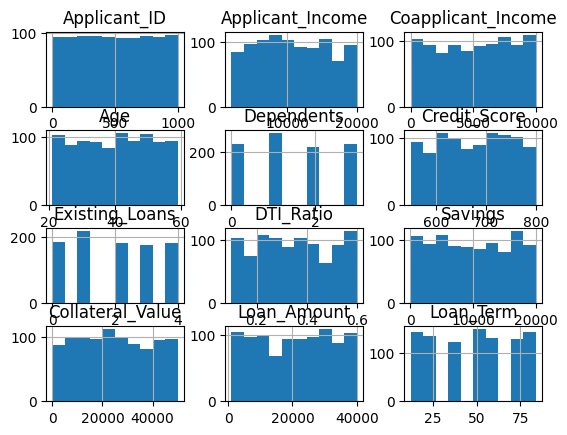

In [4]:
loan.hist()

In [5]:
loan=loan.dropna(subset=['Loan_Approved'])
loan=loan.drop('Applicant_ID',axis=1)

## Missing Data

to_mean=['Applicant_Income','Coapplicant_Income','Age','Credit_Score','DTI_Ratio','Savings','Collateral_Value','Loan_Amount','Loan_Term']
to_max=['Employment_Status','Marital_Status','Dependents','Existing_Loans','Loan_Purpose','Property_Area','Education_Level','Gender','Employer_Category']

from sklearn.impute import SimpleImputer
imp_mean = SimpleImputer(missing_values=np.nan, strategy='mean')
imp_max=SimpleImputer(strategy='most_frequent')

loan[to_mean]=imp_mean.fit_transform(loan[to_mean])
loan[to_max]=imp_max.fit_transform(loan[to_max])

## Encoding

loan['Gender']=loan['Gender'].map({'Male':1,'Female':0})
loan['Loan_Approved']=loan['Loan_Approved'].map({'Yes':1,'No':0})
loan['Marital_Status']=loan['Marital_Status'].map({'Married':1,'Single':0})
loan['Education_Level']=loan['Education_Level'].map({'Graduate':1,'Not Graduate':0})
loan['Employment_Status']=loan['Employment_Status'].map({'Self-employed':2,'Unemployed':0,'Salaried':3,'Contract':1})
loan['Property_Area']=loan['Property_Area'].map({'Urban':2,'Semiurban':1,'Rural':0})


cat=['Dependents', 'Existing_Loans']
loan[cat]=loan[cat].astype('int64')
loan=pd.get_dummies(loan,columns=['Loan_Purpose','Employer_Category'],dtype='int64')

In [6]:
## Input Out put data seperation
X=loan.drop('Loan_Approved',axis=1)
y=loan['Loan_Approved']
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 950 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Applicant_Income              950 non-null    float64
 1   Coapplicant_Income            950 non-null    float64
 2   Employment_Status             950 non-null    int64  
 3   Age                           950 non-null    float64
 4   Marital_Status                950 non-null    int64  
 5   Dependents                    950 non-null    int64  
 6   Credit_Score                  950 non-null    float64
 7   Existing_Loans                950 non-null    int64  
 8   DTI_Ratio                     950 non-null    float64
 9   Savings                       950 non-null    float64
 10  Collateral_Value              950 non-null    float64
 11  Loan_Amount                   950 non-null    float64
 12  Loan_Term                     950 non-null    float64
 13  Property_A

In [7]:
## Feature engineering
X['Total_Income']=X['Applicant_Income']+X['Coapplicant_Income']

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [9]:
## Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
acc_score=accuracy_score(y_test,y_pred)
pre_score=precision_score(y_test,y_pred)
rec_score=recall_score(y_test,y_pred)
f1_score=f1_score(y_test,y_pred)
print("Accuracy score:",acc_score)
print("Precision score:",pre_score)
print("Recall score:",rec_score)
print("f1 score:",f1_score)

Accuracy score: 0.8894736842105263
Precision score: 0.8571428571428571
Recall score: 0.7868852459016393
f1 score: 0.8205128205128205


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
clf=DecisionTreeClassifier(criterion='entropy',min_impurity_decrease=0.01)
clf.fit(X_train,y_train)
y_pred=clf.predict(X_test)

acc_score=accuracy_score(y_test,y_pred)
pre_score=precision_score(y_test,y_pred)
rec_score=recall_score(y_test,y_pred)
print("Accuracy score:",acc_score)
print("Precision score:",pre_score)
print("Recall score:",rec_score)

from sklearn.tree import plot_tree

plt.figure(figsize=(18,20))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=["Approve","Decline"],
    filled=True,
)
plt.tight_layout()
plt.show()